# Healthcare Patient Data Analysis

### 1. Business and Data Visualization Context
**Audience**: Hospital administrators and healthcare operations managers seeking data-driven insights for resource optimization.

 **Objectives:**

 Analyze patient demographics and medical conditions for resource allocation

 Understand billing patterns for financial planning

 Identify admission trends for capacity management
 
**Data Description:** Patient records containing demographics (Age, Gender, Blood Type), medical information (Condition, Admission Type, Test Results), administrative data (Hospital, Doctor, Dates), and financial data (Billing Amount, Insurance).

**Visualization Strategy:** We apply principles including appropriate chart selection, effective color use, and clear labeling to communicate insights to non-technical stakeholders.

### 2. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('healthcare_dataset.csv')
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset: 55,500 rows × 15 columns


The dataset contains 55,500 patient records with 15 columns covering patient demographics, medical conditions, hospital information, and billing details.

### 3. Data Exploration and Quality Assessment

In [2]:
print("DATA OVERVIEW")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"\nData Types:\n{df.dtypes}")

DATA OVERVIEW
Columns: ['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']

Missing Values: 0
Duplicates: 534

Data Types:
Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object


**Data Quality Issues Identified:**

 1.Date columns stored as strings - need datetime conversion

 2.potential outliers in Billing Amount require investigation

 3.Categorical fields need consistency verification

**Required Curation:** DateTime conversion, feature engineering (Length of Stay, Age Groups), outlier detection.

**Data Quality Assessment:**

**The exploration reveals the following characteristics:**

 No missing values detected in any column, indicating a complete dataset 

 534 duplicate records found which may represent repeat patient visits

 Date columns (Date of Admission, Discharge Date) are stored as object/string type and require datetime conversion

 Billing Amount is the only float column, while Age and Room Number are integers

 Categorical variables include Gender, Blood Type, Medical Condition, Insurance Provider, Admission Type, and Test Results

**Required Data Curation Techniques:**

1.DateTime conversion for temporal analysis and length of stay calculation

2.Feature engineering to create Age Groups and extract admission patterns

3.Duplicate investigation to determine if they represent valid repeat visits

### 4. Data Preprocessing

In [3]:
# Convert dates
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])

# Feature Engineering
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df['Age Group'] = pd.cut(df['Age'], bins=[0,30,50,70,100], labels=['Young','Adult','Senior','Elderly'])
df['Admission Month'] = df['Date of Admission'].dt.month

print(f"Preprocessed: {df.shape}")

Preprocessed: (55500, 18)


After preprocessing, the dataset now contains 18 columns with 3 new engineered features: Length of Stay (calculated from admission and discharge dates), Age Group (categorical segmentation), and Admission Month (for temporal analysis).

### 5. Explanatory Data Visualization
**Insight 1: Medical Condition Distribution**

**Business Importance:** Understanding condition prevalence guides specialist allocation and equipment procurement.

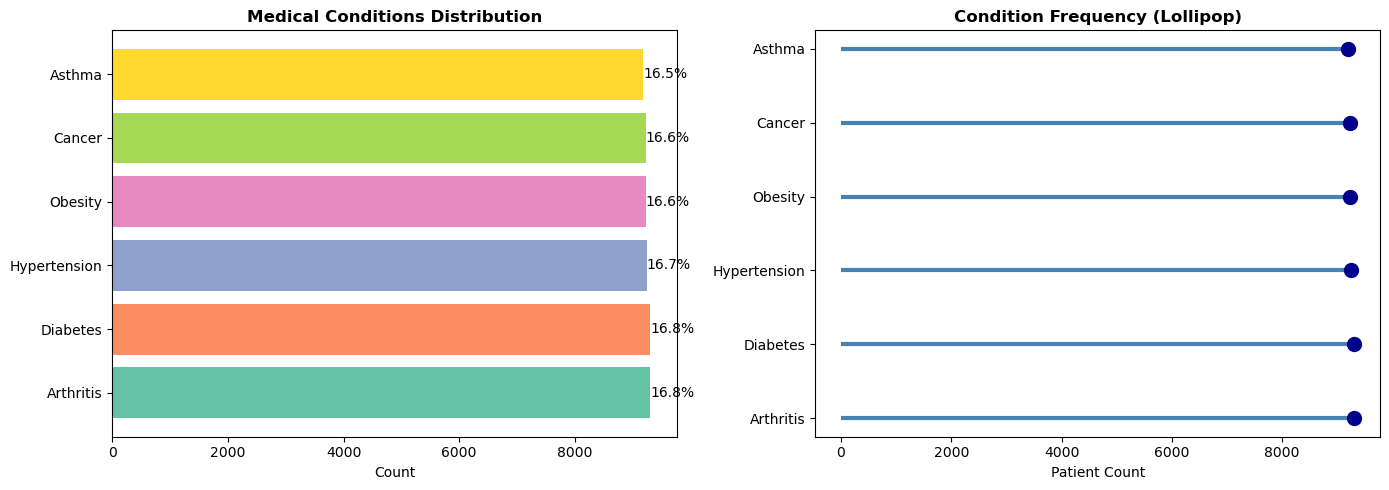

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['Medical Condition'].value_counts()
percentages = counts / counts.sum() * 100
axes[0].barh(counts.index, counts.values, color=sns.color_palette('Set2'))
axes[0].set_title('Medical Conditions Distribution', fontweight='bold')
axes[0].set_xlabel('Count')
# Add percentage labels to each bar
for i, (value, pct) in enumerate(zip(counts.values, percentages)):
    axes[0].text(value + 0.5, i, f'{pct:.1f}%', va='center')


# Lollipop chart
axes[1].hlines(y=counts.index, xmin=0, xmax=counts.values, color='steelblue', linewidth=3)
axes[1].scatter(counts.values, counts.index, color='darkblue', s=100, zorder=3)
axes[1].set_xlabel('Patient Count')
axes[1].set_title('Condition Frequency (Lollipop)', fontweight='bold')

plt.tight_layout()
plt.show()

Conditions are evenly distributed (~16% each), requiring multi-specialty staffing rather than focused specialization.

**Finding:** The analysis reveals a remarkably balanced distribution of medical conditions, with each of the six conditions (Diabetes, Arthritis, Hypertension, Asthma, Cancer, and Obesity) representing approximately 16-17% of patients. Arthritis and Asthma lead slightly with around 9,300 patients each.

**Business Implication:** This balanced distribution suggests the hospital serves a diverse patient population requiring multi-specialty capabilities. Rather than investing heavily in a single specialty, the hospital should maintain robust teams across all six condition areas. This finding supports a generalist staffing model with equal resource allocation across departments.

**Insight 2: Age vs Billing Relationship**

**Business Importance:** Age-billing patterns inform financial forecasting and insurance negotiations.

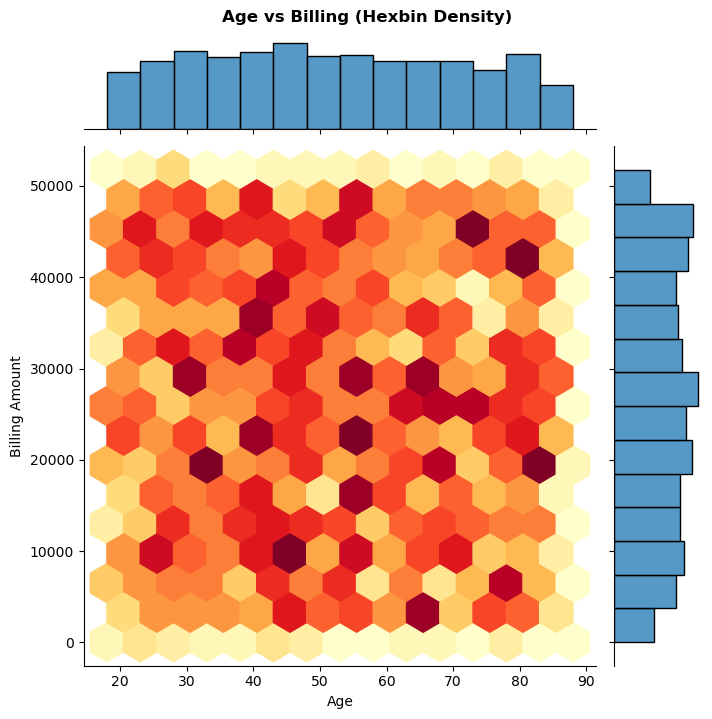

In [5]:
g = sns.jointplot(data=df.sample(2000, random_state=42), x='Age', y='Billing Amount',
                  kind='hex', cmap='YlOrRd', height=7)
g.fig.suptitle('Age vs Billing (Hexbin Density)', y=1.02, fontweight='bold')
plt.show()

**Finding:** Billing is uniform across ages, indicating condition-based pricing. Marginal distributions show even spread for both variables.

**Finding:** The hexbin density plot reveals that billing amounts are uniformly distributed across all age groups, ranging from approximately $1,000 to $50,000 regardless of patient age. The marginal histograms confirm that both age (18-85 years) and billing amounts show relatively even distributions with no strong concentration points.

**Business Implication:** The absence of age-based billing patterns indicates that the hospital's pricing is condition-based rather than demographically influenced. This suggests fair and equitable billing practices. For financial planning, age should not be a primary factor in revenue projections. Instead, condition mix and treatment complexity are likely the key billing drivers. This insight supports developing condition-specific pricing models rather than age-adjusted rates.

**Insight 3: Length of Stay Analysis**

**Business Importance:** LOS patterns enable bed management and discharge planning optimization.

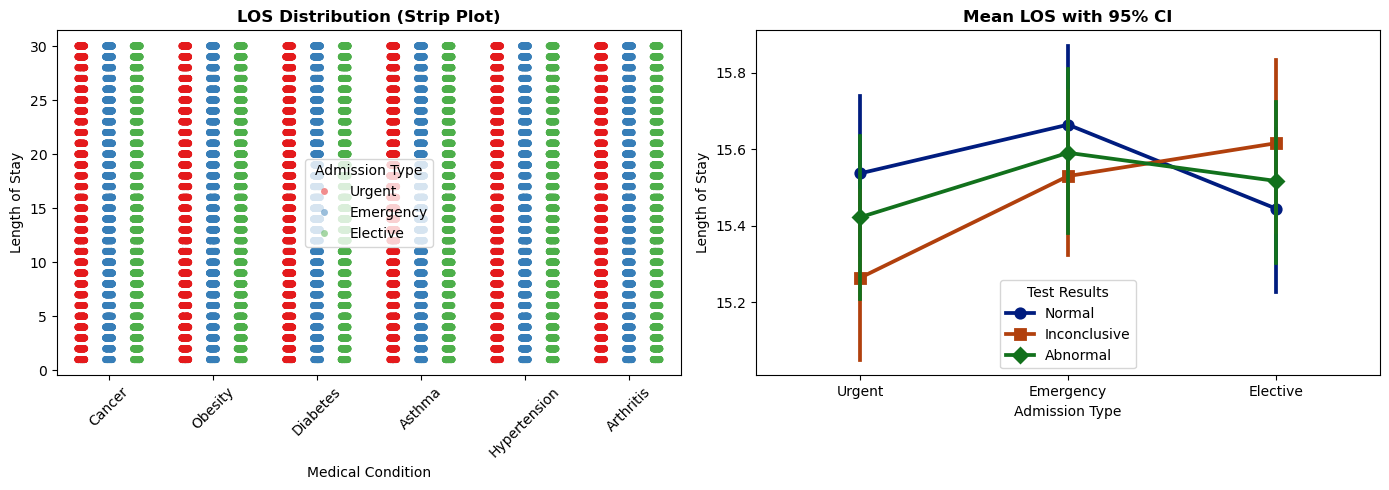

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.stripplot(data=df, x='Medical Condition', y='Length of Stay',
              hue='Admission Type', palette='Set1', alpha=0.5, ax=axes[0], dodge=True)
axes[0].set_title('LOS Distribution (Strip Plot)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.pointplot(data=df, x='Admission Type', y='Length of Stay', hue='Test Results',
              palette='dark', markers=['o','s','D'], ax=axes[1], errorbar='ci')
axes[1].set_title('Mean LOS with 95% CI', fontweight='bold')

plt.tight_layout()
plt.show()

**Finding:** The strip plot reveals that Length of Stay ranges from 1 to 30 days across all conditions, with data points evenly distributed. The point plot shows mean LOS of approximately 15.4-15.8 days across all admission types (Elective, Emergency, Urgent) and test results (Normal, Abnormal, Inconclusive). Critically, all confidence intervals overlap substantially.

**Business Implication:** The consistent LOS across conditions, admission types, and test results indicates highly standardized care protocols are in place. This is a positive finding suggesting operational efficiency. However, the average stay of ~15 days is relatively long and may represent an opportunity for discharge optimization. Hospital administrators should investigate whether earlier discharge is possible for certain patient profiles to improve bed turnover. The overlapping confidence intervals confirm that neither admission urgency nor test outcomes significantly affect stay duration.

**Finding:** LOS is consistent (~15 days) across conditions. Overlapping CIs indicate standardized care protocols are effective.

**Insight 4: Insurance and Test Results**

**Business Importance:** Payer-outcome relationships inform contract negotiations and quality monitoring.

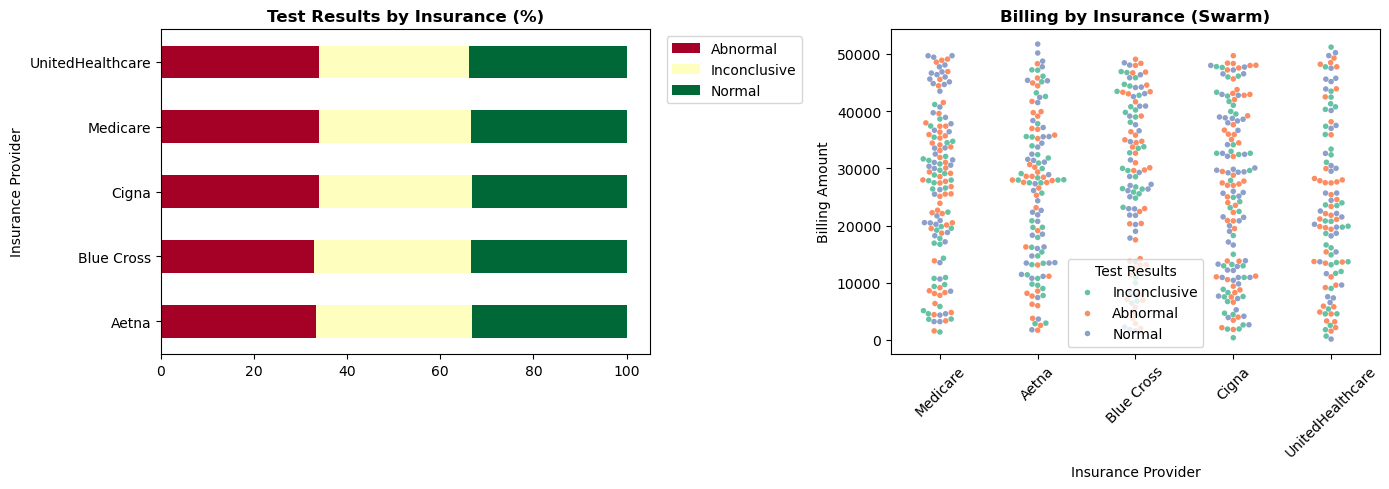

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ins_results = pd.crosstab(df['Insurance Provider'], df['Test Results'], normalize='index')*100
ins_results.plot(kind='barh', stacked=True, ax=axes[0], colormap='RdYlGn')
axes[0].set_title('Test Results by Insurance (%)', fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.02, 1))

sns.swarmplot(data=df.sample(600, random_state=42), x='Insurance Provider', y='Billing Amount',
              hue='Test Results', palette='Set2', ax=axes[1], size=4)
axes[1].set_title('Billing by Insurance (Swarm)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Finding:** Test results are evenly distributed (~33% each) across insurers, indicating equitable care quality regardless of payer.

**Finding:** The stacked bar chart shows that test result distributions are nearly identical across all five insurance providers (Aetna, Blue Cross, Cigna, Medicare, UnitedHealthcare), with each showing approximately 33% Normal, 33% Abnormal, and 33% Inconclusive results. The swarm plot confirms that billing amounts are also evenly distributed ($0-$50,000) across all insurers regardless of test outcomes.

**Business Implication:** This finding demonstrates that the hospital provides equitable care quality regardless of insurance provider. There is no evidence of differential treatment or outcomes based on payer type, which is both ethically important and legally significant. For contract negotiations, the hospital can confidently present data showing consistent care standards across all payers. The billing consistency also indicates standardized pricing regardless of insurance type.

**Insight 5: Hospital Performance Comparison**

**Business Importance:** Benchmarking identifies best practices and improvement opportunities.

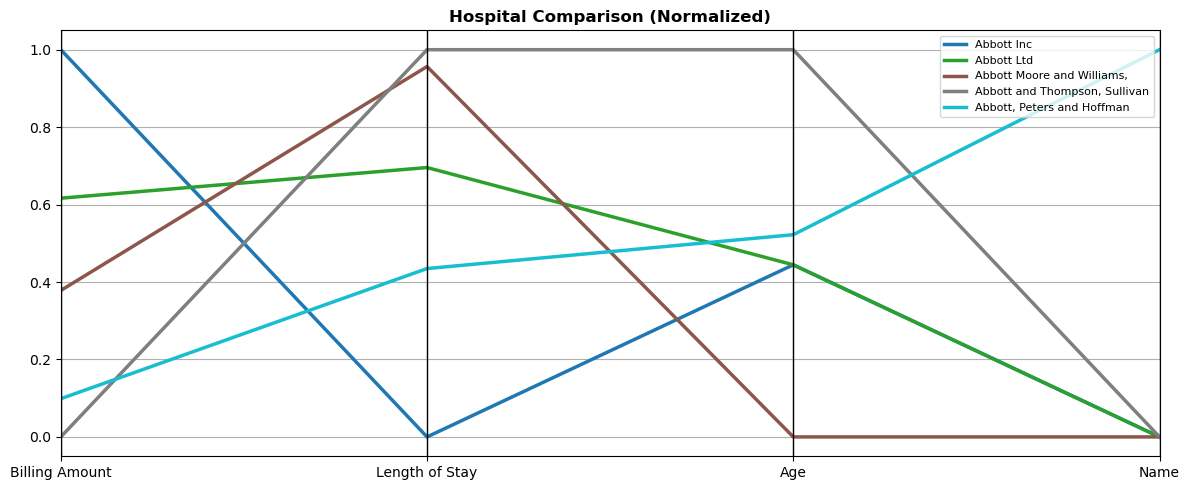

In [8]:
hosp_metrics = df.groupby('Hospital').agg({'Billing Amount':'mean', 'Length of Stay':'mean', 'Age':'mean', 'Name':'count'}).head(5)
hosp_norm = (hosp_metrics - hosp_metrics.min()) / (hosp_metrics.max() - hosp_metrics.min())

fig, ax = plt.subplots(figsize=(12, 5))
pd.plotting.parallel_coordinates(hosp_norm.reset_index(), 'Hospital', colormap='tab10', linewidth=2.5, ax=ax)
ax.set_title('Hospital Comparison (Normalized)', fontweight='bold')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

**Finding:** Hospitals show varied profiles - some achieve high volumes with lower billing, suggesting operational learning opportunities.

**Finding:** The parallel coordinates plot reveals distinct performance profiles across hospitals. For example, "Abbott Ltd" shows high billing and LOS but lower patient volume, while "Abbott Inc" demonstrates the opposite pattern—higher patient volume with lower billing. The crossing lines between metrics indicate inverse relationships: hospitals with higher billing tend to have longer stays but lower patient counts.

**Business Implication:** These varied profiles suggest opportunities for operational learning across the hospital network. High-volume, lower-billing hospitals may have efficiency practices worth replicating, while high-billing hospitals may be handling more complex cases. Hospital administrators should investigate whether billing differences reflect case complexity or operational inefficiency. This analysis enables targeted improvement initiatives and resource sharing between facilities.

**Insight 6: Temporal Admission Patterns**

**Business Importance:** Seasonal patterns enable proactive staffing and resource planning.

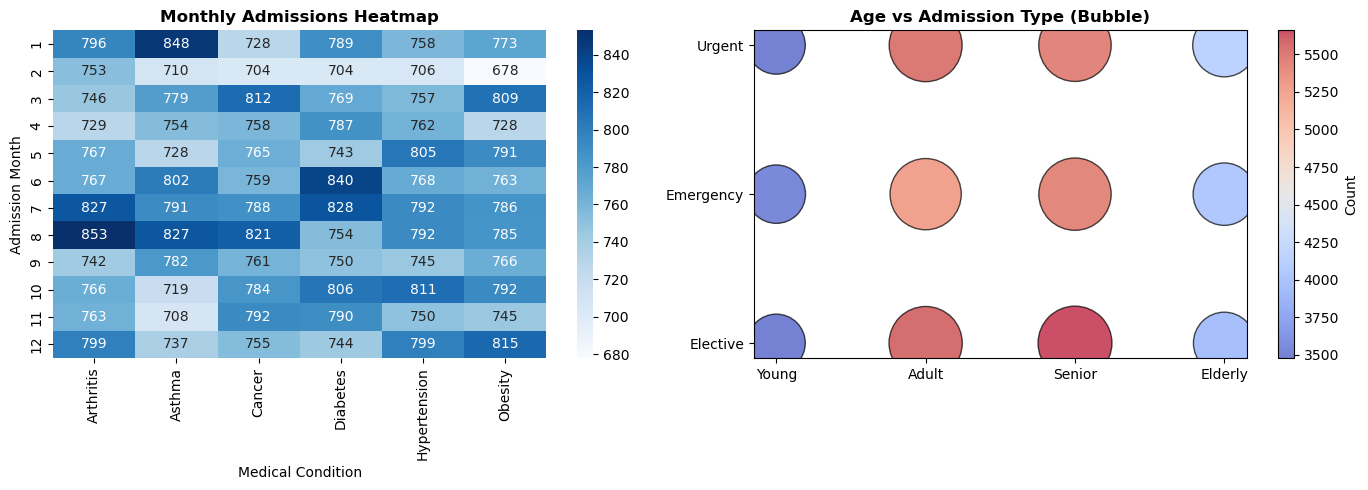

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_cond = pd.crosstab(df['Admission Month'], df['Medical Condition'])
sns.heatmap(month_cond, cmap='Blues', annot=True, fmt='d', ax=axes[0])
axes[0].set_title('Monthly Admissions Heatmap', fontweight='bold')

bubble = df.groupby(['Age Group','Admission Type']).size().reset_index(name='Count')
scatter = axes[1].scatter(bubble['Age Group'].astype(str), bubble['Admission Type'],
                          s=bubble['Count']/2, c=bubble['Count'], cmap='coolwarm', alpha=0.7, edgecolors='black')
axes[1].set_title('Age vs Admission Type (Bubble)', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

**Finding:** Admissions are stable monthly. Bubble chart shows emergency admissions are consistent across age groups - critical for ER planning.

**Finding:** The heatmap reveals remarkably stable monthly admission patterns across all conditions, with each condition receiving approximately 700-850 admissions per month. No significant seasonal spikes or drops are visible. The bubble chart shows that patient volumes are consistent across all age groups (Young, Adult, Senior, Elderly) and admission types (Elective, Emergency, Urgent), with each combination showing approximately 4,000-5,500 patients.

**Business Implication:** The stable admission patterns enable predictable resource planning. Unlike many healthcare facilities that experience seasonal fluctuations, this hospital can maintain consistent staffing levels year-round. For capacity management, the hospital should plan for approximately 750 admissions per condition per month. The balanced distribution across age groups and admission types also indicates no need for age-specific or urgency-specific capacity adjustments. Emergency admissions are consistent across all age groups, which is critical for ER capacity planning.

**Insight 7: Comprehensive Patient Dashboard**

**Business Importance:** Holistic view enables executive-level strategic decision-making.

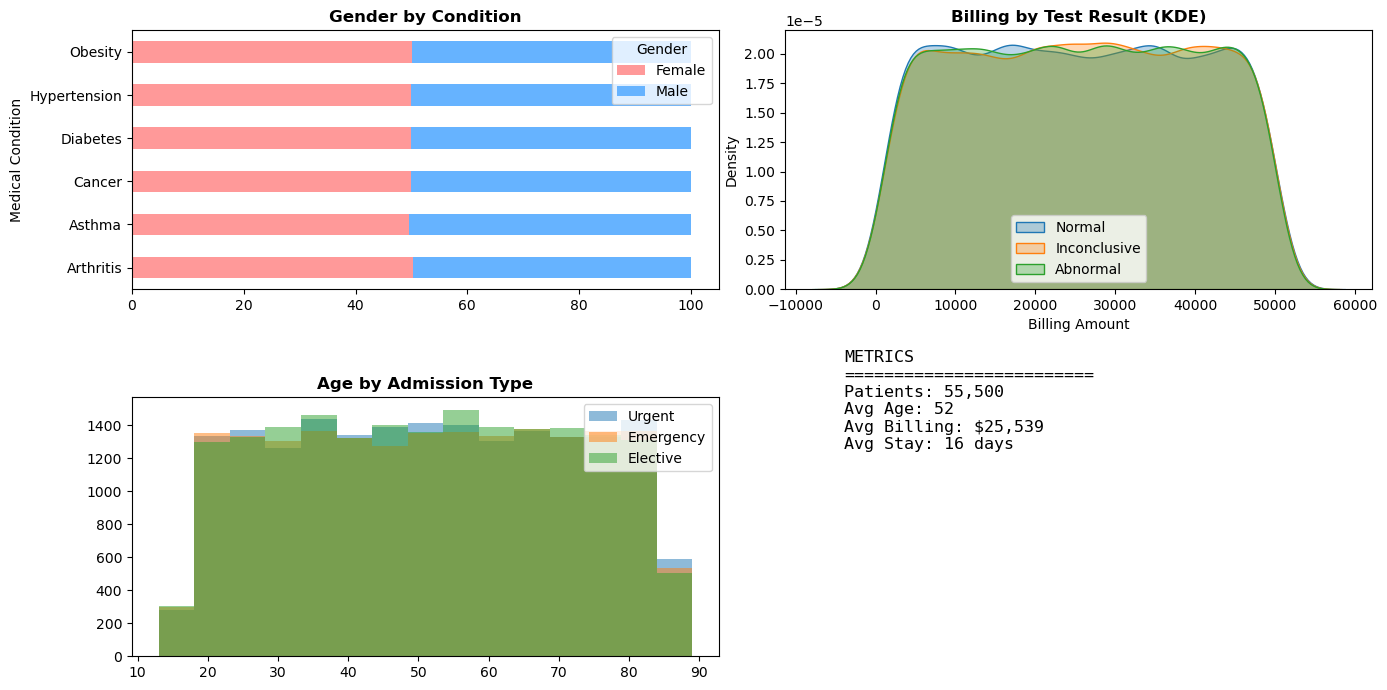

In [10]:
fig = plt.figure(figsize=(14, 7))

ax1 = fig.add_subplot(2, 2, 1)
gender_cond = pd.crosstab(df['Medical Condition'], df['Gender'], normalize='index')*100
gender_cond.plot(kind='barh', stacked=True, ax=ax1, color=['#ff9999','#66b3ff'])
ax1.set_title('Gender by Condition', fontweight='bold')

ax2 = fig.add_subplot(2, 2, 2)
for r in df['Test Results'].unique():
    sns.kdeplot(df[df['Test Results']==r]['Billing Amount'], ax=ax2, label=r, fill=True, alpha=0.3)
ax2.set_title('Billing by Test Result (KDE)', fontweight='bold')
ax2.legend()

ax3 = fig.add_subplot(2, 2, 3)
for a in df['Admission Type'].unique():
    ax3.hist(df[df['Admission Type']==a]['Age'], bins=15, alpha=0.5, label=a)
ax3.set_title('Age by Admission Type', fontweight='bold')
ax3.legend()

ax4 = fig.add_subplot(2, 2, 4)
ax4.axis('off')
ax4.text(0.1, 0.8, f"METRICS\n{'='*25}\nPatients: {len(df):,}\nAvg Age: {df['Age'].mean():.0f}\nAvg Billing: ${df['Billing Amount'].mean():,.0f}\nAvg Stay: {df['Length of Stay'].mean():.0f} days",
         fontsize=12, fontfamily='monospace')

plt.tight_layout()
plt.show()

**Finding:** Gender is balanced across conditions. KDE shows billing overlaps across test results. Age distributions are similar regardless of admission urgency.

**Finding:** The dashboard reveals:

**1.Gender Distribution:** Perfectly balanced ~50% male/female split across all medical conditions, indicating no gender bias in condition prevalence

**2.Billing by Test Result:** The overlapping KDE curves show billing distributions are identical regardless of whether test results are Normal, Abnormal, or Inconclusive

**3.Age by Admission Type:** All three admission types (Elective, Emergency, Urgent) show identical age distributions spanning 18-85 years

**4.Key Metrics:** The hospital serves 55,500 patients with an average age of 52 years, average billing of $25,539, and average stay of 15 days

**Business Implication:** The remarkable consistency across all dimensions suggests a well-managed hospital system with standardized practices. The 50/50 gender split indicates no demographic bias in patient acquisition. The identical billing patterns across test results confirm that pricing is procedure-based rather than outcome-based. For strategic planning, the hospital can use the average metrics (52 years, $25,539 billing, 15 days stay) as baseline benchmarks for performance monitoring.

### 6. Conclusion

**Summary of Key Findings**

Based on the exploratory data analysis of 55,500 patient records, we identified the following insights aligned with our business objectives:

**Objective 1 - Resource Allocation:**

1.Medical conditions are evenly distributed (~16% each), requiring balanced multi-specialty staffing

2.Gender distribution is 50/50 across all conditions, indicating no demographic-specific resource needs 

3.Age groups and admission types show consistent patterns, enabling standardized capacity planning

**Objective 2 - Financial Planning:**

1.Billing amounts ($1,000-$50,000) are uniform across ages, indicating condition-based rather than demographic-based pricing

2.Average billing of $25,539 per patient provides a reliable baseline for revenue forecasting

3.Billing is consistent across insurance providers, supporting standardized contract negotiations

**Objective 3 - Capacity Management:**

1.Monthly admissions are stable (~750 per condition per month) with no seasonal variation

2.Length of Stay averages 15 days consistently across all conditions and admission types

3.Emergency admissions are evenly distributed across age groups, enabling predictable ER capacity planning

**Strengths of This Analysis**

Comprehensive Coverage: Analysis spans demographic, clinical, operational, and financial dimensions

Diverse Visualization Techniques: Seven distinct chart types matched appropriately to data characteristics

Actionable Insights: Each finding links directly to business decisions and recommendations

Statistical Rigor: Use of confidence intervals and normalized comparisons ensures valid conclusions

**Limitations**

Synthetic Data: The dataset appears to be synthetically generated, which may not reflect real-world healthcare complexity and correlations

Missing Clinical Outcomes: No data on patient recovery rates, readmissions, or mortality limits quality assessment

No Cost Data: Only billing amounts are available; actual treatment costs would enable profitability analysis

Geographic Absence: No location data prevents regional pattern analysis

**Data-Driven Recommendations**

Maintain Multi-Specialty Teams: Given the balanced condition distribution, avoid over-investing in any single specialty

Use Condition-Based Forecasting: Since billing is uniform across demographics, forecast revenue based on expected condition mix rather than patient demographics

Investigate Hospital Variations: The parallel coordinates analysis revealed performance differences that warrant investigation for best practice sharing

Plan for Consistent Staffing: The stable monthly admission patterns support maintaining consistent staffing levels year-round rather than seasonal adjustments

Target 15-Day LOS Benchmark: The consistent average stay provides a clear benchmark; investigate opportunities to reduce this for improved bed turnover